# Premières architectures de LeCun

In [ ]:
import torch
import torch.nn as nn

In [2]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
class LeNet1989(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet1989, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5)      # 1x28x28 -> 4x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 4x24x24 -> 4x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(4, 12, kernel_size=5)     # 4x12x12 -> 12x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 12x8x8 -> 12x4x4

        # Fully connected
        self.fc1   = nn.Linear(12*4*4, 60)
        self.fc2   = nn.Linear(60, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)   # logits
        return x


In [4]:
class LeNet5(nn.Module):  # 1998
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)      # 1x28x28 -> 6x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 6x24x24 -> 6x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)     # 6x12x12 -> 16x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 16x8x8 -> 16x4x4

        # Fully connected
        self.fc1   = nn.Linear(16*4*4, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # logits
        return x


# La convolution

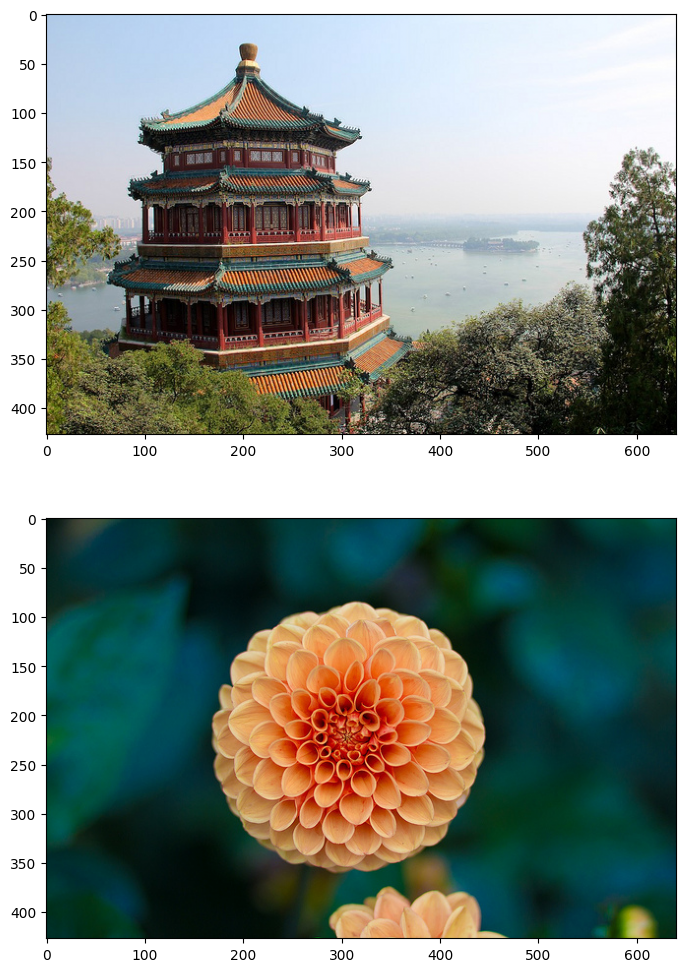

In [5]:
import numpy as np
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt

# Load sample images
china = load_sample_image("china.jpg") / 255.
flower = load_sample_image("flower.jpg") / 255.

fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].imshow(china)
ax[1].imshow(flower)

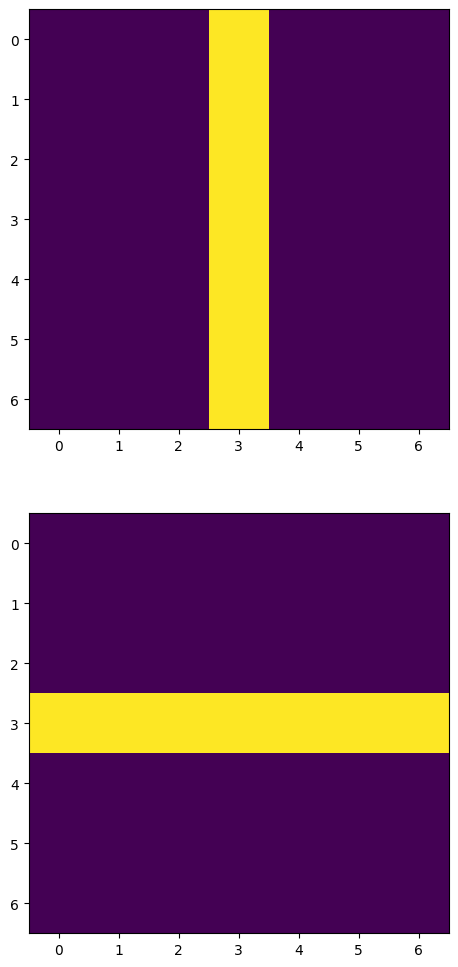

In [6]:
# Create a batch of images
images = np.array([china, flower])
batch_size, height, width, channels = images.shape

# Create 2 filters: one vertical and one horizontal
filters = np.zeros(shape=(2, channels, 7, 7), dtype=np.float32)
filters[0, :, :, 3] = 1  # vertical line
filters[1, :, 3, :] = 1  # horizontal line

fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].imshow(filters[0, 0, :, :])
ax[1].imshow(filters[1, 0, :, :])

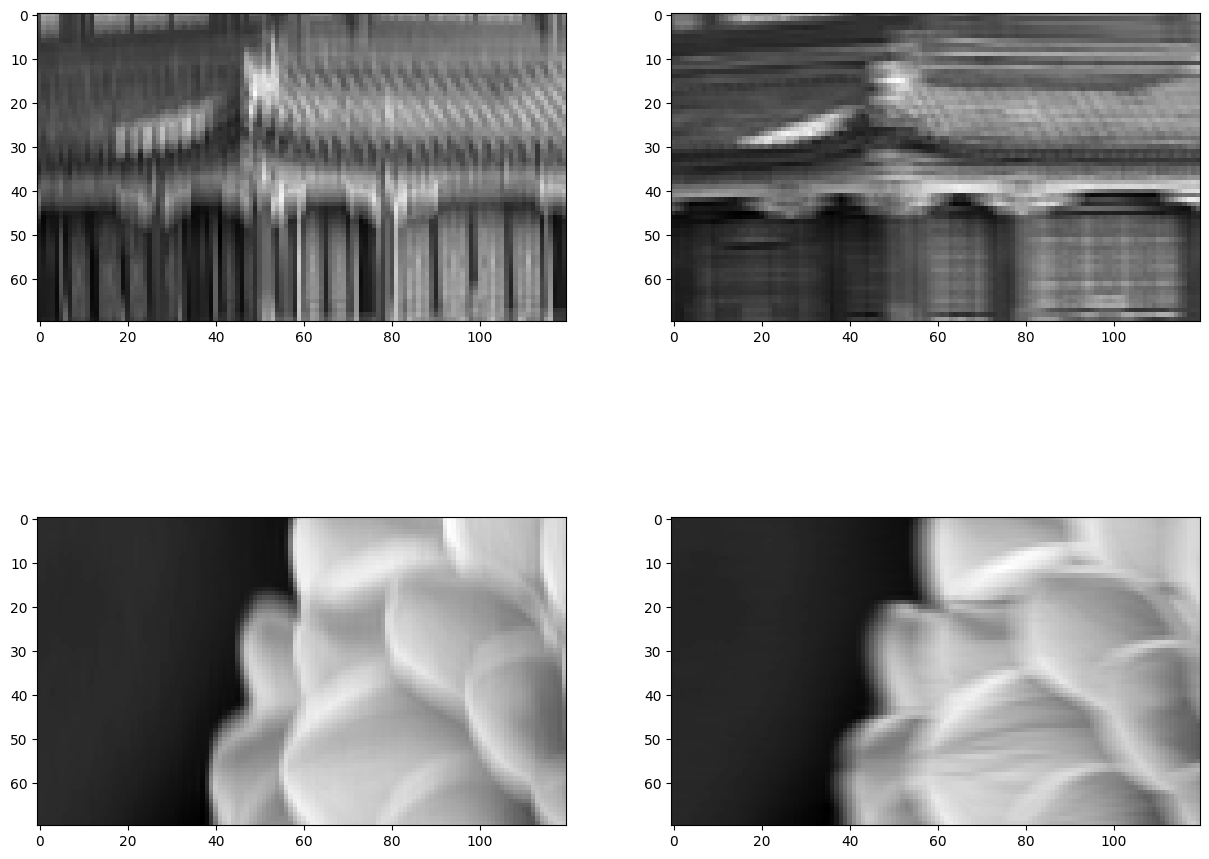

In [7]:
conv_layers = torch.nn.Conv2d(in_channels=3, out_channels=2, kernel_size=7, stride=1, padding="same")
conv_layers.weight = torch.nn.Parameter(torch.tensor(filters))

outputs = conv_layers(torch.tensor(images, dtype=torch.float32).permute([0, 3, 1 ,2])).detach()

def crop(images):
    return images[150:220, 130:250]


fig, ax = plt.subplots(2, 2, figsize=(15, 12))

ax[0, 0].imshow(crop(outputs[0, 0, :, :]), cmap='gray')
ax[0, 1].imshow(crop(outputs[0, 1, :, :]), cmap='gray')

ax[1, 0].imshow(crop(outputs[1, 0, :, :]), cmap='gray')
ax[1, 1].imshow(crop(outputs[1, 1, :, :]), cmap='gray')

# Exercice modification LeNet-5
Modifier afin d'intégrer le GlobalAvgPooling et vérifier les formats de sorties des 2 modèles sur une image au format native et une autre non native

In [8]:
x_natif = torch.randn((1, 1, 28, 28))  # Format natif
x_other = torch.randn((1, 1, 256, 512))  # Format non natif

In [9]:
class LeNet5_GAP(nn.Module): 
    def __init__(self, num_classes=10):
        super(LeNet5_GAP, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)      # 1x28x28 -> 6x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 6x24x24 -> 6x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)     # 6x12x12 -> 16x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 16x8x8 -> 16x4x4

        # Fully connected
        self.fc1   = nn.Linear(16, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.mean(x, dim=(2, 3))
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # logits
        return x


In [10]:
lenet5 = LeNet5(10)
lenet5_gap = LeNet5_GAP(10)

print(lenet5(x_natif).shape)
print(lenet5_gap(x_natif).shape)

torch.Size([1, 10])
torch.Size([1, 10])


In [11]:
print(lenet5_gap(x_other).shape)
print(lenet5(x_other).shape)  #-> erreur

torch.Size([1, 10])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x122000 and 256x120)

# Exercice : Voir architecture MLP utiliser sur MNIST et comparer le nombre de paramètres entre MLP et CNN ainsi que les performances entre les deux

In [12]:
import torch
from torch import nn


class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers, num_classes):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, num_classes)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = nn.Softmax(dim=1)(self.output_layer(h))

        return y
    
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype("int64") 

In [13]:
mlp_mnist_classifier = MLP(in_shape=X.shape[1], n_neurons=16, num_hiddens_layers=1, num_classes=10).to(device)
# Assuming mnist_classifier is already defined
total_params = sum(p.numel() for p in mlp_mnist_classifier.parameters())
trainable_params = sum(p.numel() for p in mlp_mnist_classifier.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 13002
Trainable parameters: 13002


In [14]:
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32) / 255.
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]
    

# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(mlp_mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
dataset = MNISTDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Entraînement
n_epochs = 10
for epoch in range(1, n_epochs+1):
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in dataloader:  # Mini-Batch
        # Forward pass
        y_pred = mlp_mnist_classifier(xb.to(device))

        # Loss
        loss = criterion(y_pred, yb.to(device))

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

        # Accuracy
        preds = torch.argmax(y_pred.cpu(), dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Epoch   1 | Loss: 1.6685 | Accuracy: 81.76%
Epoch   2 | Loss: 1.5505 | Accuracy: 91.72%
Epoch   3 | Loss: 1.5364 | Accuracy: 92.90%
Epoch   4 | Loss: 1.5291 | Accuracy: 93.53%
Epoch   5 | Loss: 1.5243 | Accuracy: 93.96%
Epoch   6 | Loss: 1.5207 | Accuracy: 94.29%
Epoch   7 | Loss: 1.5179 | Accuracy: 94.47%
Epoch   8 | Loss: 1.5154 | Accuracy: 94.74%
Epoch   9 | Loss: 1.5135 | Accuracy: 94.94%
Epoch  10 | Loss: 1.5119 | Accuracy: 95.08%


In [15]:
import torch
import torch.nn as nn

class LeNet5_GAP(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5_GAP, self).__init__()
        # Convolutions
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)   # sortie: 6x(H-4)x(W-4)
        self.pool1 = nn.AvgPool2d(2)                  # 6x(H-4)/2 x (W-4)/2

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)  # 16x(H-4-4)/2 ? 
        self.pool2 = nn.AvgPool2d(2)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1,1))  # réduit n'importe quelle spatial à 1x1

        # Fully connected
        self.fc = nn.Linear(16, num_classes)    # car après GAP, taille = 16x1x1 -> 16

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = self.gap(x)                # 16xHxW -> 16x1x1
        x = torch.flatten(x, 1)        # 16x1x1 -> 16
        x = self.fc(x)
        return x


cnn_mnist_classifier = LeNet5_GAP(num_classes=10).to(device)

# Assuming mnist_classifier is already defined
total_params = sum(p.numel() for p in cnn_mnist_classifier.parameters())
trainable_params = sum(p.numel() for p in cnn_mnist_classifier.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 2742
Trainable parameters: 2742


In [16]:
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]
    

# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(cnn_mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
dataset = MNISTDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Entraînement
n_epochs = 10
for epoch in range(1, n_epochs+1):
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in dataloader:  # Mini-Batch
        # Forward pass
        y_pred = cnn_mnist_classifier(xb.to(device))

        # Loss
        loss = criterion(y_pred, yb.to(device))

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

        # Accuracy
        preds = torch.argmax(y_pred.cpu(), dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Epoch   1 | Loss: 1.5430 | Accuracy: 55.46%
Epoch   2 | Loss: 0.7037 | Accuracy: 85.37%
Epoch   3 | Loss: 0.4088 | Accuracy: 91.49%
Epoch   4 | Loss: 0.2815 | Accuracy: 93.70%
Epoch   5 | Loss: 0.2195 | Accuracy: 94.81%
Epoch   6 | Loss: 0.1847 | Accuracy: 95.40%
Epoch   7 | Loss: 0.1627 | Accuracy: 95.78%
Epoch   8 | Loss: 0.1463 | Accuracy: 96.14%
Epoch   9 | Loss: 0.1344 | Accuracy: 96.40%
Epoch  10 | Loss: 0.1245 | Accuracy: 96.66%


### Avec moins de paramètres pour le CNN on obtient de meilleures performances que sur MLP

# Transfer Learning
Comparer un modèle pré-entrainé à un modèle from scratch

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import time
import numpy as np

# ===========================
# Hyperparamètres
# ===========================
batch_size = 64
num_classes = 10
num_epochs = 5
learning_rate = 0.001
subset_fraction = 0.1  # 10% du dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# Dataset & DataLoader
# ===========================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# On ne garde qu'une fraction du dataset pour accentuer l'effet transfer learning
subset_size = int(len(train_dataset_full) * subset_fraction)
subset_indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
train_dataset = Subset(train_dataset_full, subset_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# ===========================
# Fonctions d'entraînement et d'évaluation
# ===========================
def train_model(model, criterion, optimizer, num_epochs):
    model = model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} - Time: {time.time()-start_time:.1f}s")

def evaluate_model(model):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = correct / total
    print(f"Test Accuracy: {acc:.4f}")
    return acc

# ===========================
# 1) Model from scratch
# ===========================
print("=== Training from scratch (10% dataset) ===")
model_scratch = models.mobilenet_v2(pretrained=False)
model_scratch.classifier[1] = nn.Linear(model_scratch.last_channel, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=learning_rate)

train_model(model_scratch, criterion, optimizer, num_epochs)
acc_scratch = evaluate_model(model_scratch)

# ===========================
# 2) Transfer Learning
# ===========================
print("\n=== Transfer Learning (10% dataset) ===")
model_tl = models.mobilenet_v2(pretrained=True)
for param in model_tl.features.parameters():
    param.requires_grad = False  # gèle les couches convolutives

model_tl.classifier[1] = nn.Linear(model_tl.last_channel, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tl.classifier.parameters(), lr=learning_rate)

train_model(model_tl, criterion, optimizer, num_epochs)
acc_tl = evaluate_model(model_tl)

print(f"\nAccuracy from scratch: {acc_scratch:.4f}")
print(f"Accuracy with transfer learning: {acc_tl:.4f}")

c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


=== Training from scratch (10% dataset) ===


c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/5] - Loss: 1.9270 - Acc: 0.2850 - Time: 9.3s
Epoch [2/5] - Loss: 1.6600 - Acc: 0.3926 - Time: 8.0s
Epoch [3/5] - Loss: 1.5259 - Acc: 0.4460 - Time: 8.0s
Epoch [4/5] - Loss: 1.4259 - Acc: 0.4812 - Time: 7.8s
Epoch [5/5] - Loss: 1.3199 - Acc: 0.5164 - Time: 7.8s
Test Accuracy: 0.4668

=== Transfer Learning (10% dataset) ===


c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5] - Loss: 1.4429 - Acc: 0.5234 - Time: 10.4s
Epoch [2/5] - Loss: 0.9418 - Acc: 0.6998 - Time: 4.9s
Epoch [3/5] - Loss: 0.8507 - Acc: 0.7178 - Time: 4.6s
Epoch [4/5] - Loss: 0.7766 - Acc: 0.7388 - Time: 4.5s
Epoch [5/5] - Loss: 0.7403 - Acc: 0.7498 - Time: 4.6s
Test Accuracy: 0.7460

Accuracy from scratch: 0.4668
Accuracy with transfer learning: 0.7460


# Exercice autoencodeurs

In [18]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# --- 1. Dataset avec bruit gaussien ---
class NoisyFashionMNIST(Dataset):
    def __init__(self, train=True, noise_std=0.3):
        self.dataset = torchvision.datasets.FashionMNIST(
            root="./data", train=train, download=True, transform=transforms.ToTensor()
        )
        self.noise_std = noise_std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]   # img: [1,28,28], valeurs [0,1]
        noisy_img = img + torch.randn_like(img) * self.noise_std
        noisy_img = torch.clamp(noisy_img, 0., 1.)  # garder dans [0,1]
        return noisy_img, img  # x = bruité, y = original

# --- 2. Dataloader ---
train_dataset = NoisyFashionMNIST(train=True)
test_dataset  = NoisyFashionMNIST(train=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# --- 3. Autoencodeur convolutionnel simple ---
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()  # pour rester dans [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# --- 4. Exemple d'entraînement ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Boucle d'entraînement rapide. Une seule epoch suffit.
count = 0
for epoch in range(1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        count += 1
        if count == 110:  # L'augmenter de 10 en 10 en exécutant la cellule d'après pour voir l'évolution
            break
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")


Epoch 1, Loss: 0.0077


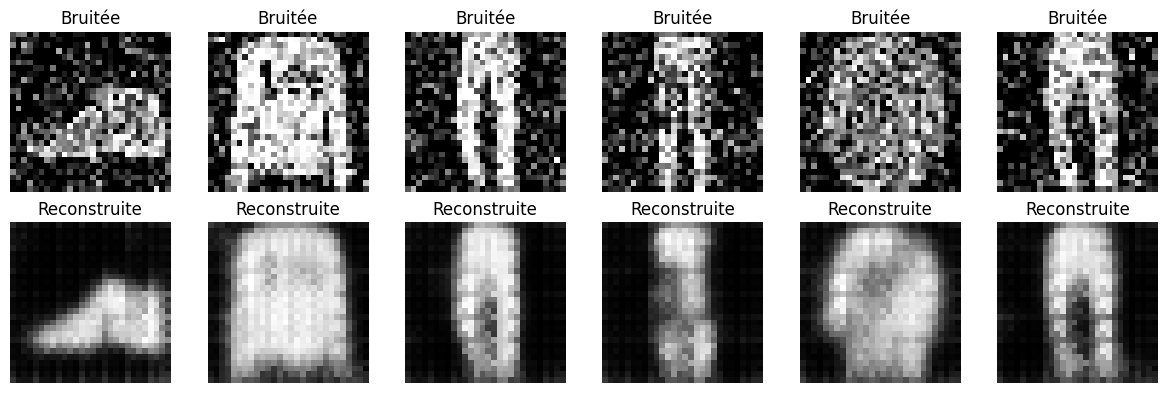

In [19]:
import matplotlib.pyplot as plt
import torch

# Assurer que le modèle est en mode évaluation
model.eval()

# Récupérer un batch de test
x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

# Prédiction du modèle
with torch.no_grad():
    y_pred = model(x_batch)

# Visualisation des 6 premières images
n = 6
plt.figure(figsize=(12, 4))
for i in range(n):
    # Image bruitée
    plt.subplot(2, n, i+1)
    plt.imshow(x_batch[i].cpu().squeeze(), cmap='gray')
    plt.title("Bruitée")
    plt.axis('off')
    
    # Image reconstruite
    plt.subplot(2, n, i+1+n)
    plt.imshow(y_pred[i].cpu().squeeze(), cmap='gray')
    plt.title("Reconstruite")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Exercice : Détection d’anomalie par extraction de caractéristiques

Étape 3 : Estimation de la distribution normale...
Distribution calculée. Forme du tenseur moyen : torch.Size([256, 14, 14])
Étape 4 : Inférence sur une image de test...


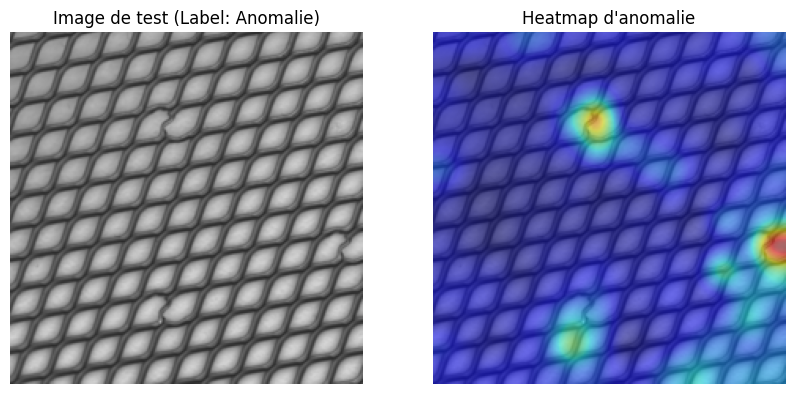

In [20]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 16

# =====================================================================
# ÉTAPE 1 : Le Dataset MVTec (CORRIGÉ)
# =====================================================================
class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, is_train=True, transform=None):
        self.root_dir = root_dir
        self.category = category
        self.is_train = is_train
        self.transform = transform
        
        self.image_paths = []
        self.labels = [] 
        
        self._load_dataset()

    def _load_dataset(self):
        category_dir = os.path.join(self.root_dir, self.category)
        
        if self.is_train:
            # Train contient uniquement des images saines ('good')
            good_images = glob.glob(os.path.join(category_dir, "train", "good", "*.png"))
            self.image_paths.extend(good_images)
            self.labels.extend([0] * len(good_images))
        else:
            # Test contient 'good' (sains = 0) et plusieurs types de défauts (anomalies = 1)
            test_dir = os.path.join(category_dir, "test")
            subfolders = os.listdir(test_dir)
            
            for folder in subfolders:
                folder_path = os.path.join(test_dir, folder)
                if not os.path.isdir(folder_path):
                    continue
                
                images = glob.glob(os.path.join(folder_path, "*.png"))
                self.image_paths.extend(images)
                
                if folder == "good":
                    self.labels.extend([0] * len(images))
                else:
                    self.labels.extend([1] * len(images))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Lecture en RGB pour s'aligner sur les canaux attendus par ImageNet
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Transformations standards ImageNet
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# =====================================================================
# ÉTAPE 2 : Extracteur de Features (CORRIGÉ)
# =====================================================================
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # Chargement des poids mis à jour selon l'API récente de torchvision
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Un ResNet18 possède 10 enfants principaux. 
        # Les indices 0 à 6 correspondent à : conv1, bn1, relu, maxpool, layer1, layer2, layer3.
        # On exclut layer4 (trop de perte de résolution spatiale) et les couches de classification.
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:7])
        
        # Freeze des gradients pour l'inférence stricte
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
            
        self.eval()

    def forward(self, x):
        return self.feature_extractor(x)


# =====================================================================
# ÉTAPE 3 : Modélisation de la Normalité (Train) - CORRIGÉ
# =====================================================================
def train_distribution(feature_extractor, train_loader):
    feature_extractor.eval()
    all_features = []
    
    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(DEVICE)
            features = feature_extractor(images)
            all_features.append(features.cpu())
            
    # Concaténation sur la dimension du batch -> [N, C, H, W]
    all_features = torch.cat(all_features, dim=0)
    
    # Estimation empirique par pixel-position (dim=0 calcule les stats à travers le batch N)
    mean = all_features.mean(dim=0)
    var = all_features.var(dim=0, unbiased=False)
    
    return mean, var


# =====================================================================
# ÉTAPE 4 : Inférence et Génération de la Heatmap (CORRIGÉ)
# =====================================================================
def predict_anomaly_map(feature_extractor, test_image, mean, var, epsilon=1e-5):
    feature_extractor.eval()
    with torch.no_grad():
        test_feat = feature_extractor(test_image)
    
    test_feat = test_feat.squeeze(0).cpu() # [C, H_feat, W_feat]
    
    # Calcul de Mahalanobis diagonale : sqrt( sum( (x - mu)^2 / var ) )
    # On somme sur la dimension des canaux (dim=0)
    anomaly_map = torch.sqrt(torch.sum(((test_feat - mean) ** 2) / (var + epsilon), dim=0))
    
    # Préparation pour F.interpolate -> requiert [B, C, H, W]
    anomaly_map = anomaly_map.unsqueeze(0).unsqueeze(0)
    
    # Upsampling bilinéaire vers la résolution d'origine
    anomaly_map_resized = F.interpolate(
        anomaly_map, 
        size=(IMAGE_SIZE, IMAGE_SIZE), 
        mode='bilinear', 
        align_corners=False
    )
    
    # Extraction du tenseur 2D natif
    anomaly_map_resized = anomaly_map_resized.squeeze().numpy()
    
    # Filtrage gaussien spatial pour adoucir les contours de la carte thermique
    anomaly_map_smoothed = gaussian_filter(anomaly_map_resized, sigma=4)
    
    return anomaly_map_smoothed


# =====================================================================
# SCRIPT PRINCIPAL DE VÉRIFICATION
# =====================================================================
if __name__ == "__main__":
    # Remplace par ton arborescence locale si nécessaire
    DATA_PATH = "../datasets/anomaly_detection" 
    CATEGORY = "grid"
    
    train_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=False, transform=transform)
    
    extractor = FeatureExtractor().to(DEVICE)
    
    print("Étape 3 : Estimation de la distribution normale...")
    mean, var = train_distribution(extractor, train_loader)
    print(f"Distribution calculée. Forme du tenseur moyen : {mean.shape}") # Attendu: [256, 14, 14] pour ResNet18/Layer3
    
    print("Étape 4 : Inférence sur une image de test...")
    # Sélection d'une image anormale à des fins de démonstration visuelle
    anomaly_indices = [i for i, label in enumerate(test_dataset.labels) if label == 1]
    if len(anomaly_indices) > 0:
        sample_idx = anomaly_indices[np.random.randint(0, len(anomaly_indices))]
    else:
        sample_idx = np.random.randint(0, len(test_dataset))
        
    img_tensor, label = test_dataset[sample_idx]
    
    heatmap = predict_anomaly_map(extractor, img_tensor.unsqueeze(0).to(DEVICE), mean, var)
    
    # Post-traitement de l'image pour affichage Matplotlib
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    orig_img = inv_normalize(img_tensor).permute(1, 2, 0).clip(0, 1).numpy()
    
    # Tracé
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Image de test (Label: {'Anomalie' if label == 1 else 'Sain'})")
    plt.imshow(orig_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Heatmap d'anomalie")
    plt.imshow(orig_img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5) 
    plt.axis('off')
    plt.show()

# Exercice modèle multimodale (optionnel)

In [21]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from os.path import join
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from torchvision.io import read_image

In [22]:
class FlipkartDataset(Dataset):
    def __init__(self):
        self.metadata = pd.read_csv('../datasets/Flipkart/flipkart_com-ecommerce_sample_1050.csv')

        # Text data
        vectorizer = CountVectorizer()
        self.x_text = torch.tensor(vectorizer.fit_transform(self.metadata['description'].values).todense(), dtype=torch.float32)
        self.x_text /= self.x_text.max()


        # Image data
        self.x_images = []
        images_path = '../datasets/Flipkart/Images'
        for image_filename in self.metadata['image'].tolist():
            image_tensor = torch.nn.Upsample(size=(1080, 1080))(read_image(join(images_path, image_filename)).unsqueeze(0)) / 255.
            self.x_images.append(image_tensor)
        self.x_images = torch.cat(self.x_images, dim=0)

        # Label data
        self.y = self.metadata['product_category_tree'].apply(lambda x: x.split(' >> ')[0][2:])
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y)
        
    def __len__(self):
        return len(self.x_images)

    def __getitem__(self, idx):
        return self.x_images[idx], self.x_text[idx], self.y[idx]

In [23]:
batch_size = 2

dataset = FlipkartDataset()
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

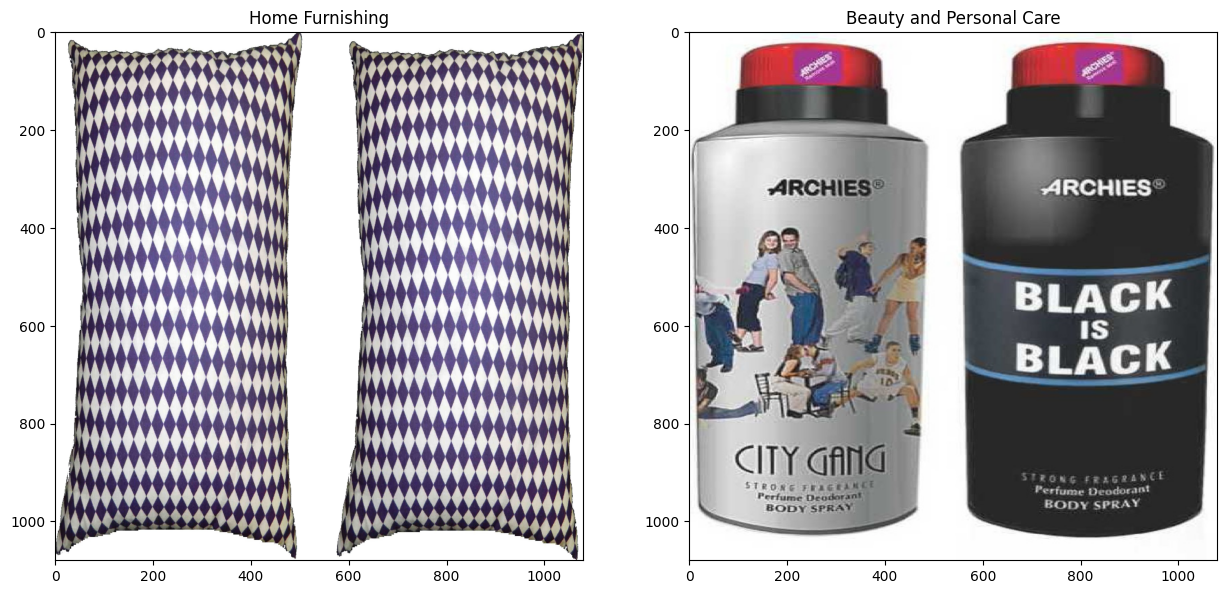

In [24]:
# A relancer plusieurs fois
fig, axs = plt.subplots(batch_size//2, 2)

fig.set_size_inches(15, 15)
axs = axs.ravel()

for images, _, y in dataloader:
    y = dataset.le.inverse_transform(y)
    for i in range(batch_size):
        axs[i].imshow(images[i].permute([1, 2, 0]))
        axs[i].set_title(y[i])
    break


In [25]:
dataset.le.classes_

array(['Baby Care', 'Beauty and Personal Care', 'Computers',
       'Home Decor & Festive Needs', 'Home Furnishing',
       'Kitchen & Dining', 'Watches'], dtype=object)

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridModel(nn.Module):
    def __init__(self, text_dim=6053, num_classes=7):
        super(HybridModel, self).__init__()
        
        # --- Text branch ---
        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        
        # --- Image branch ---
        self.img_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),  # (32, 540, 540)
            nn.ReLU(),
            nn.MaxPool2d(2),                                       # (32, 270, 270)
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # (64, 135, 135)
            nn.ReLU(),
            nn.MaxPool2d(2),                                       # (64, 67, 67)
        )
        
        # Flatten conv output → project to 256-dim embedding
        conv_out_dim = 64 * 67 * 67
        self.img_fc = nn.Sequential(
            nn.Linear(conv_out_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        
        # --- Fusion & classification ---
        self.classifier = nn.Sequential(
            nn.Linear(256 + 256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, text_x, img_x):
        # text_x: (batch, 6053)
        # img_x:  (batch, 3, 1080, 1080)
        
        text_feat = self.text_fc(text_x)  # (batch, 256)
        
        img_feat = self.img_conv(img_x)
        img_feat = img_feat.view(img_feat.size(0), -1)  # flatten
        img_feat = self.img_fc(img_feat)                # (batch, 256)
        
        fused = torch.cat([text_feat, img_feat], dim=1)  # (batch, 512)
        out = self.classifier(fused)                     # (batch, 7)
        return out


In [ ]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score
import numpy as np

# --- Hyperparameters ---
BATCH_SIZE = 2
LR = 1e-4
EPOCHS = 50
PATIENCE = 5  # early stopping patience
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Très lent en CPU

# --- Dataset / DataLoader ---
dataset = FlipkartDataset()

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Model, Loss, Optimizer ---
model = HybridModel().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# --- Training Loop with Early Stopping ---
best_val_acc = 0
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    train_preds, train_targets = [], []
    
    for x_img, x_txt, y in train_loader:
        y = y.long()
        x_img, x_txt, y = x_img.to(DEVICE), x_txt.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x_txt.float(), x_img.float())
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_preds.append(out.argmax(dim=1).cpu())
        train_targets.append(y.cpu())
    
    train_preds = torch.cat(train_preds)
    train_targets = torch.cat(train_targets)
    train_acc = accuracy_score(train_targets, train_preds)
    
    # --- Validation ---
    model.eval()
    val_losses = []
    val_preds, val_targets = [], []
    with torch.no_grad():
        for x_img, x_txt, y in val_loader:
            y = y.long()
            x_img, x_txt, y = x_img.to(DEVICE), x_txt.to(DEVICE), y.to(DEVICE)
            out = model(x_txt.float(), x_img.float())
            loss = criterion(out, y)
            val_losses.append(loss.item())
            val_preds.append(out.argmax(dim=1).cpu())
            val_targets.append(y.cpu())
    
    val_preds = torch.cat(val_preds)
    val_targets = torch.cat(val_targets)
    val_acc = accuracy_score(val_targets, val_preds)
    
    print(f"Epoch {epoch+1}: "
          f"Train Loss={np.mean(train_losses):.4f}, Acc={100*train_acc:.2f} % | "
          f"Val Loss={np.mean(val_losses):.4f}, Acc={100*val_acc:.2f} %")
    
    # --- Early stopping ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # torch.save(model.state_dict(), "best_hybrid_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# # --- Load best model ---
# model.load_state_dict(torch.load("best_hybrid_model.pth"))
# print("Training finished. Best validation accuracy:", best_val_acc)

In [27]:
metadata = pd.read_csv('../datasets/Flipkart/flipkart_com-ecommerce_sample_1050.csv')

In [28]:
print(metadata.loc[2, 'description'])

Key Features of Eurospa Cotton Terry Face Towel Set Size: small Height: 9 inch GSM: 360,Eurospa Cotton Terry Face Towel Set (20 PIECE FACE TOWEL SET, Assorted) Price: Rs. 299 Eurospa brings to you an exclusively designed, 100% soft cotton towels of export quality. All our products have soft texture that takes care of your skin and gives you that enriched feeling you deserve. Eurospa has been exporting its bath towels to lot of renowned brands for last 10 years and is famous for its fine prints, absorbency, softness and durability. NOTE: Our product is 100% cotton, so it is susceptible to shrinkage. Product color may vary from the picture. Size may vary by ±3% WASH CARE: Wash in cold Water, Do not Iron, Do not Bleach, Flat dry, Wash before first use. SIZE- FACE TOWEL - 23 cms X 23 cms.,Specifications of Eurospa Cotton Terry Face Towel Set (20 PIECE FACE TOWEL SET, Assorted) Bath Towel Features Material Cotton Terry Design SHUVAM General Brand Eurospa GSM 360 Type Face Towel Set Model Na

In [29]:
print(metadata.loc[0, 'product_category_tree'])

["Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do..."]
